# All Experiments Overview

This notebook is the consolidated visualization for the current 16-to-4 CARLA wireless channel-prediction experiments.

The LSTM/LWM rule is strict:

- Include `lstm` and `lwm` only when the checkpoint uses the current wideband-time embedding.
- Wideband-time is detected by checkpoint input dimension `Na * Nsc * 2 = 16 * 64 * 2 = 2048`.
- Exclude older per-subcarrier `lstm`/`lwm` runs with input dimension `32`.
- `lwm_temporal` and `chiron` are patch-time models and are included normally.

All tables and plots below are generated from the filtered run set. No legacy exported PNGs are displayed.

In [1]:
from pathlib import Path
import json
import math
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

ip = get_ipython()
if ip is not None:
    ip.run_line_magic('matplotlib', 'inline')

try:
    import torch
except ImportError:
    torch = None
    warnings.warn('torch is not available; LSTM/LWM checkpoint shape detection cannot run.')

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

NOTEBOOK_DIR = Path.cwd().resolve()

def find_repo_root(start: Path) -> Path | None:
    for candidate in [start, *start.parents]:
        if (candidate / 'multimodal_code_index/run_multimodal_16to4').exists():
            return candidate
    return None

repo_root = find_repo_root(NOTEBOOK_DIR)
if repo_root is not None:
    RUN_ROOT = repo_root / 'multimodal_code_index/run_multimodal_16to4/outputs'
elif NOTEBOOK_DIR.name == 'all_experiments_overview':
    RUN_ROOT = NOTEBOOK_DIR.parent.parent
else:
    RUN_ROOT = Path('..').resolve().parent

CHECKPOINT_DIR = RUN_ROOT / 'checkpoints'
FIGURES_ROOT = RUN_ROOT / 'figures'
CONSOLIDATED_DIR = FIGURES_ROOT / 'all_experiments_overview'

print('Notebook dir:', NOTEBOOK_DIR)
print('Run root:', RUN_ROOT)
print('Checkpoint dir:', CHECKPOINT_DIR)
print('Checkpoint dir exists:', CHECKPOINT_DIR.exists())

Notebook dir: /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/figures/all_experiments_overview
Run root: /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs
Checkpoint dir: /mnt/ssd_7t_2/carla-wireless-dataset/multimodal_code_index/run_multimodal_16to4/outputs/checkpoints
Checkpoint dir exists: True


## Load Histories With Wideband LSTM/LWM Filtering

The checkpoint file is the source of truth for the LSTM/LWM embedding type.

In [2]:
SCENARIO_RE = re.compile(r'sc\d+', re.IGNORECASE)
MODEL_ORDER = ['lstm', 'lwm', 'lwm_temporal', 'chiron']
MODE_ORDER = ['channel_only', 'multimodal', 'image_only']
EPOCH_LIMIT = 20
WIDEBAND_INPUT_DIM = 16 * 64 * 2

def infer_scenario(path: Path, args: dict) -> str:
    scenarios = args.get('scenarios') or []
    if isinstance(scenarios, list) and scenarios:
        return str(scenarios[0]).lower()
    for key in ('scenario', 'data_dir', 'run_name'):
        value = args.get(key)
        if isinstance(value, str):
            match = SCENARIO_RE.search(value)
            if match:
                return match.group(0).lower()
    match = SCENARIO_RE.search(path.name)
    return match.group(0).lower() if match else 'unknown'

def infer_mode(path: Path, args: dict) -> str:
    mode = args.get('mode')
    if mode:
        return str(mode)
    name = path.name
    if 'channel_only' in name:
        return 'channel_only'
    if 'multimodal' in name:
        return 'multimodal'
    if 'image_only' in name:
        return 'image_only'
    return 'unknown'

def infer_model(path: Path, data: dict, args: dict) -> str:
    model = args.get('model') or data.get('model_name')
    if model:
        return str(model)
    name = path.name
    for candidate in MODEL_ORDER:
        if candidate in name:
            return candidate
    return 'unknown'

def checkpoint_path_from_history(path: Path, data: dict) -> Path | None:
    candidates = []
    checkpoint = data.get('checkpoint')
    if checkpoint:
        cp = Path(checkpoint)
        candidates.append(cp if cp.is_absolute() else path.parent / cp)
    candidates.append(path.with_name(path.name.replace('_history.json', '_best.pt')))
    for candidate in candidates:
        if candidate.exists():
            return candidate
    return None

def detect_channel_input_dim(checkpoint_path: Path | None, model: str) -> int | None:
    if checkpoint_path is None or torch is None or model not in {'lstm', 'lwm'}:
        return None
    raw = torch.load(checkpoint_path, map_location='cpu')
    state = raw.get('model_state_dict', raw) if isinstance(raw, dict) else raw
    key = 'lstm.weight_ih_l0' if model == 'lstm' else 'embedding.proj.weight'
    weight = state.get(key)
    return int(weight.shape[1]) if weight is not None else None

def embedding_variant(path: Path, data: dict, model: str) -> tuple[str, int | None, str | None]:
    checkpoint_path = checkpoint_path_from_history(path, data)
    checkpoint_name = checkpoint_path.name if checkpoint_path is not None else None
    if model not in {'lstm', 'lwm'}:
        return 'patch_time', None, checkpoint_name
    input_dim = detect_channel_input_dim(checkpoint_path, model)
    if input_dim == WIDEBAND_INPUT_DIM:
        return 'wideband_time', input_dim, checkpoint_name
    if input_dim == 32:
        return 'per_subcarrier_legacy', input_dim, checkpoint_name
    return 'unknown_lstm_lwm_embedding', input_dim, checkpoint_name

def load_history_file(path: Path) -> tuple[list[dict], dict]:
    data = json.loads(path.read_text())
    args = data.get('args') or {}
    scenario = infer_scenario(path, args)
    mode = infer_mode(path, args)
    model = infer_model(path, data, args)
    run_id = path.stem.replace('_history', '')
    mtime = pd.Timestamp(path.stat().st_mtime, unit='s')
    variant, input_dim, checkpoint_name = embedding_variant(path, data, model)

    rows = []
    cumulative_time_s = 0.0
    for item in data.get('history', []):
        cumulative_time_s += float(item.get('time_s') or 0.0)
        train = item.get('train') or {}
        val = item.get('val') or {}
        rows.append({
            'run_id': run_id,
            'source_file': path.name,
            'checkpoint_file': checkpoint_name,
            'mtime': mtime,
            'scenario': scenario,
            'mode': mode,
            'model': model,
            'embedding_variant': variant,
            'channel_input_dim': input_dim,
            'epoch': item.get('epoch'),
            'time_hours': cumulative_time_s / 3600.0,
            'lr': item.get('lr'),
            'train_loss': train.get('loss'),
            'val_loss': val.get('loss'),
            'train_nmse_db': train.get('nmse_db'),
            'val_nmse_db': val.get('nmse_db'),
            'train_cosine_sim': train.get('cosine_sim'),
            'val_cosine_sim': val.get('cosine_sim'),
            'num_parameters': data.get('num_parameters'),
            'arg_epochs': args.get('epochs'),
            'batch_size': args.get('batch_size'),
            'seed': args.get('seed'),
            'amp': args.get('amp'),
            'amp_dtype': args.get('amp_dtype'),
            'device': args.get('device'),
        })
    meta = {
        'run_id': run_id,
        'source_file': path.name,
        'checkpoint_file': checkpoint_name,
        'scenario': scenario,
        'mode': mode,
        'model': model,
        'embedding_variant': variant,
        'channel_input_dim': input_dim,
        'mtime': mtime,
        'epochs_in_file': len(data.get('history', [])),
    }
    return rows, meta

all_rows = []
all_meta = []
for path in sorted(CHECKPOINT_DIR.glob('*history.json')):
    rows, meta = load_history_file(path)
    all_rows.extend(rows)
    all_meta.append(meta)

all_history_df = pd.DataFrame(all_rows)
all_metadata_df = pd.DataFrame(all_meta)

is_legacy_lstm_lwm = (
    all_metadata_df['model'].isin(['lstm', 'lwm'])
    & all_metadata_df['channel_input_dim'].ne(WIDEBAND_INPUT_DIM)
)
metadata_df = all_metadata_df[~is_legacy_lstm_lwm].copy()
excluded_metadata_df = all_metadata_df[is_legacy_lstm_lwm].copy()

keep_run_ids = set(metadata_df['run_id'])
history_df = all_history_df[all_history_df['run_id'].isin(keep_run_ids)].copy()

print(f'History files before filtering: {len(all_metadata_df)}')
print(f'History files kept: {len(metadata_df)}')
print(f'Legacy LSTM/LWM files excluded: {len(excluded_metadata_df)}')
print(f'Epoch rows kept: {len(history_df)}')

display(Markdown('### Included runs'))
display(metadata_df.sort_values(['scenario', 'mode', 'model', 'mtime']))

display(Markdown('### Excluded legacy LSTM/LWM runs'))
display(excluded_metadata_df.sort_values(['scenario', 'mode', 'model', 'mtime'])[[
    'scenario', 'mode', 'model', 'embedding_variant', 'channel_input_dim', 'source_file'
]])

History files before filtering: 25
History files kept: 17
Legacy LSTM/LWM files excluded: 8
Epoch rows kept: 350


### Included runs

,run_id,source_file,checkpoint_file,scenario,mode,model,embedding_variant,channel_input_dim,mtime,epochs_in_file
6,multimodal4_channel_only_sc01_K16_P4_img8_chiron,multimodal4_channel_only_sc01_K16_P4_img8_chir...,multimodal4_channel_only_sc01_K16_P4_img8_chir...,sc01,channel_only,chiron,patch_time,NaN,2026-05-14 02:38:08.294123650,30
20,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,sc01,channel_only,lstm,wideband_time,2048.0,2026-05-29 22:48:44.109319448,20
21,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,post_lstm_lwm_wideband_amp_epochs20_20260529_2...,sc01,channel_only,lwm,wideband_time,2048.0,2026-05-30 08:17:17.711475611,20
9,multimodal4_channel_only_sc01_K16_P4_img8_seed...,multimodal4_channel_only_sc01_K16_P4_img8_seed...,multimodal4_channel_only_sc01_K16_P4_img8_seed...,sc01,channel_only,lwm_temporal,patch_time,NaN,2026-05-21 17:40:51.832777023,20
14,multimodal4_multimodal_sc01_K16_P4_img8_chiron,multimodal4_multimodal_sc01_K16_P4_img8_chiron...,multimodal4_multimodal_sc01_K16_P4_img8_chiron...,sc01,multimodal,chiron,patch_time,NaN,2026-05-21 14:25:14.141461611,20
22,post_lstm_lwm_wideband_amp_recovery_20260530_1...,post_lstm_lwm_wideband_amp_recovery_20260530_1...,post_lstm_lwm_wideband_amp_recovery_20260530_1...,sc01,multimodal,lstm,wideband_time,2048.0,2026-05-30 22:51:49.216381788,20
4,channel_only_temporal_chiron_noamp_20260603_16...,channel_only_temporal_chiron_noamp_20260603_16...,channel_only_temporal_chiron_noamp_20260603_16...,sc03,channel_only,chiron,patch_time,NaN,2026-06-04 12:40:54.159068823,20
2,channel_only_sc08_sc03_amp_20260601_165600_sc0...,channel_only_sc08_sc03_amp_20260601_165600_sc0...,channel_only_sc08_sc03_amp_20260601_165600_sc0...,sc03,channel_only,lstm,wideband_time,2048.0,2026-06-02 11:29:44.167946577,20
3,channel_only_sc08_sc03_amp_20260601_165600_sc0...,channel_only_sc08_sc03_amp_20260601_165600_sc0...,channel_only_sc08_sc03_amp_20260601_165600_sc0...,sc03,channel_only,lwm,wideband_time,2048.0,2026-06-02 21:04:23.501268625,20
10,multimodal4_channel_only_sc04_K16_P4_img8_chiron,multimodal4_channel_only_sc04_K16_P4_img8_chir...,multimodal4_channel_only_sc04_K16_P4_img8_chir...,sc04,channel_only,chiron,patch_time,NaN,2026-05-23 19:10:49.272238731,20


### Excluded legacy LSTM/LWM runs

,scenario,mode,model,embedding_variant,channel_input_dim,source_file
7,sc01,channel_only,lstm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc01_K16_P4_img8_lstm...
8,sc01,channel_only,lwm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc01_K16_P4_img8_lwm_...
15,sc01,multimodal,lstm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc01_K16_P4_img8_lstm_h...
16,sc01,multimodal,lwm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc01_K16_P4_img8_lwm_hi...
11,sc04,channel_only,lstm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc04_K16_P4_img8_lstm...
12,sc04,channel_only,lwm,per_subcarrier_legacy,32.0,multimodal4_channel_only_sc04_K16_P4_img8_lwm_...
18,sc04,multimodal,lstm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc04_K16_P4_img8_lstm_h...
19,sc04,multimodal,lwm,per_subcarrier_legacy,32.0,multimodal4_multimodal_sc04_K16_P4_img8_lwm_hi...


## Compact Summary Table

Values are computed over a common 20-epoch comparison window.

In [3]:
if history_df.empty:
    raise RuntimeError('No history rows remain after wideband filtering.')

limited = history_df[history_df['epoch'].le(EPOCH_LIMIT)].copy()

best_idx = limited.groupby('run_id')['val_nmse_db'].idxmin()
best20 = limited.loc[best_idx].copy().rename(columns={
    'epoch': 'best_epoch',
    'val_nmse_db': 'best_val_nmse_db',
    'val_loss': 'best_val_loss',
    'val_cosine_sim': 'best_val_cosine_sim',
    'train_nmse_db': 'train_nmse_db_at_best',
    'train_loss': 'train_loss_at_best',
})

final_idx = limited.groupby('run_id')['epoch'].idxmax()
final20 = limited.loc[final_idx, [
    'run_id', 'epoch', 'train_nmse_db', 'val_nmse_db', 'val_loss', 'val_cosine_sim'
]].rename(columns={
    'epoch': 'final_epoch',
    'train_nmse_db': 'final_train_nmse_db',
    'val_nmse_db': 'final_val_nmse_db',
    'val_loss': 'final_val_loss',
    'val_cosine_sim': 'final_val_cosine_sim',
})

summary20 = best20.merge(final20, on='run_id', how='left')
summary20['train_val_nmse_gap_db_at_best'] = summary20['best_val_nmse_db'] - summary20['train_nmse_db_at_best']
summary20['epoch_limit'] = EPOCH_LIMIT

canonical = (
    summary20
    .sort_values(['scenario', 'mode', 'model', 'mtime'])
    .drop_duplicates(['scenario', 'mode', 'model'], keep='last')
    .copy()
)

display_cols = [
    'scenario', 'mode', 'model', 'embedding_variant', 'channel_input_dim',
    'best_epoch', 'best_val_nmse_db', 'best_val_loss',
    'final_epoch', 'final_val_nmse_db', 'final_val_loss',
    'train_nmse_db_at_best', 'train_val_nmse_gap_db_at_best', 'source_file'
]

display(
    canonical.sort_values(['scenario', 'mode', 'model'])[display_cols]
    .style.format({
        'channel_input_dim': lambda x: '' if pd.isna(x) else f'{int(x)}',
        'best_val_nmse_db': '{:.3f}',
        'best_val_loss': '{:.3e}',
        'final_val_nmse_db': '{:.3f}',
        'final_val_loss': '{:.3e}',
        'train_nmse_db_at_best': '{:.3f}',
        'train_val_nmse_gap_db_at_best': '{:.3f}',
    })
)

,scenario,mode,model,embedding_variant,channel_input_dim,best_epoch,best_val_nmse_db,best_val_loss,final_epoch,final_val_nmse_db,final_val_loss,train_nmse_db_at_best,train_val_nmse_gap_db_at_best,source_file
6,sc01,channel_only,chiron,patch_time,,17,-46.018,8.761e-04,20,-45.995,9.119e-04,-49.144,3.126,multimodal4_channel_only_sc01_K16_P4_img8_chiron_history.json
12,sc01,channel_only,lstm,wideband_time,2048,3,-34.676,1.298e-03,20,-28.968,1.710e-03,-32.947,-1.729,post_lstm_lwm_wideband_amp_epochs20_20260529_233331_channel_only_lstm_history.json
13,sc01,channel_only,lwm,wideband_time,2048,5,-29.577,1.701e-03,20,-28.968,1.710e-03,-27.706,-1.872,post_lstm_lwm_wideband_amp_epochs20_20260529_233331_channel_only_lwm_history.json
7,sc01,channel_only,lwm_temporal,patch_time,,20,-51.540,5.251e-04,20,-51.540,5.251e-04,-67.161,15.621,multimodal4_channel_only_sc01_K16_P4_img8_seed42_lwm_temporal_history.json
10,sc01,multimodal,chiron,patch_time,,5,-37.423,8.773e-04,20,-35.473,9.734e-04,-43.501,6.078,multimodal4_multimodal_sc01_K16_P4_img8_chiron_history.json
14,sc01,multimodal,lstm,wideband_time,2048,13,-31.856,1.805e-03,20,-29.663,2.063e-03,-36.144,4.288,post_lstm_lwm_wideband_amp_recovery_20260530_1255_multimodal_lstm_history.json
4,sc03,channel_only,chiron,patch_time,,19,-38.598,4.410e-05,20,-38.539,4.464e-05,-36.908,-1.691,channel_only_temporal_chiron_noamp_20260603_162358_sc03_channel_only_chiron_history.json
2,sc03,channel_only,lstm,wideband_time,2048,17,-35.359,1.067e-04,20,-35.064,1.076e-04,-34.574,-0.785,channel_only_sc08_sc03_amp_20260601_165600_sc03_channel_only_lstm_history.json
3,sc03,channel_only,lwm,wideband_time,2048,1,-27.792,8.955e-04,20,-24.386,1.911e-03,-24.009,-3.782,channel_only_sc08_sc03_amp_20260601_165600_sc03_channel_only_lwm_history.json
8,sc04,channel_only,chiron,patch_time,,20,-34.458,1.054e-02,20,-34.458,1.054e-02,-52.190,17.733,multimodal4_channel_only_sc04_K16_P4_img8_chiron_history.json


In [4]:
coverage = (
    canonical.assign(available=1)
    .pivot_table(index=['scenario', 'mode'], columns='model', values='available', aggfunc='max', fill_value=0)
    .reindex(columns=MODEL_ORDER, fill_value=0)
    .sort_index()
)
display(Markdown('### Coverage after wideband LSTM/LWM filtering'))
display(coverage)

best_by_scenario = (
    canonical.sort_values('best_val_nmse_db')
    .groupby('scenario', as_index=False)
    .first()[['scenario', 'mode', 'model', 'best_epoch', 'best_val_nmse_db']]
)
display(Markdown('### Best result per scenario'))
display(best_by_scenario.style.format({'best_val_nmse_db': '{:.3f}'}))

### Coverage after wideband LSTM/LWM filtering

model                  lstm  lwm  lwm_temporal  chiron
scenario mode                                         
sc01     channel_only     1    1             1       1
         multimodal       1    0             0       1
sc03     channel_only     1    1             0       1
sc04     channel_only     1    1             1       1
         multimodal       0    0             0       1
sc08     channel_only     1    1             0       1

### Best result per scenario

,scenario,mode,model,best_epoch,best_val_nmse_db
0,sc01,channel_only,lwm_temporal,20,-51.540
1,sc03,channel_only,chiron,19,-38.598
2,sc04,channel_only,lwm_temporal,19,-37.048
3,sc08,channel_only,chiron,20,-45.283


## Best Validation NMSE

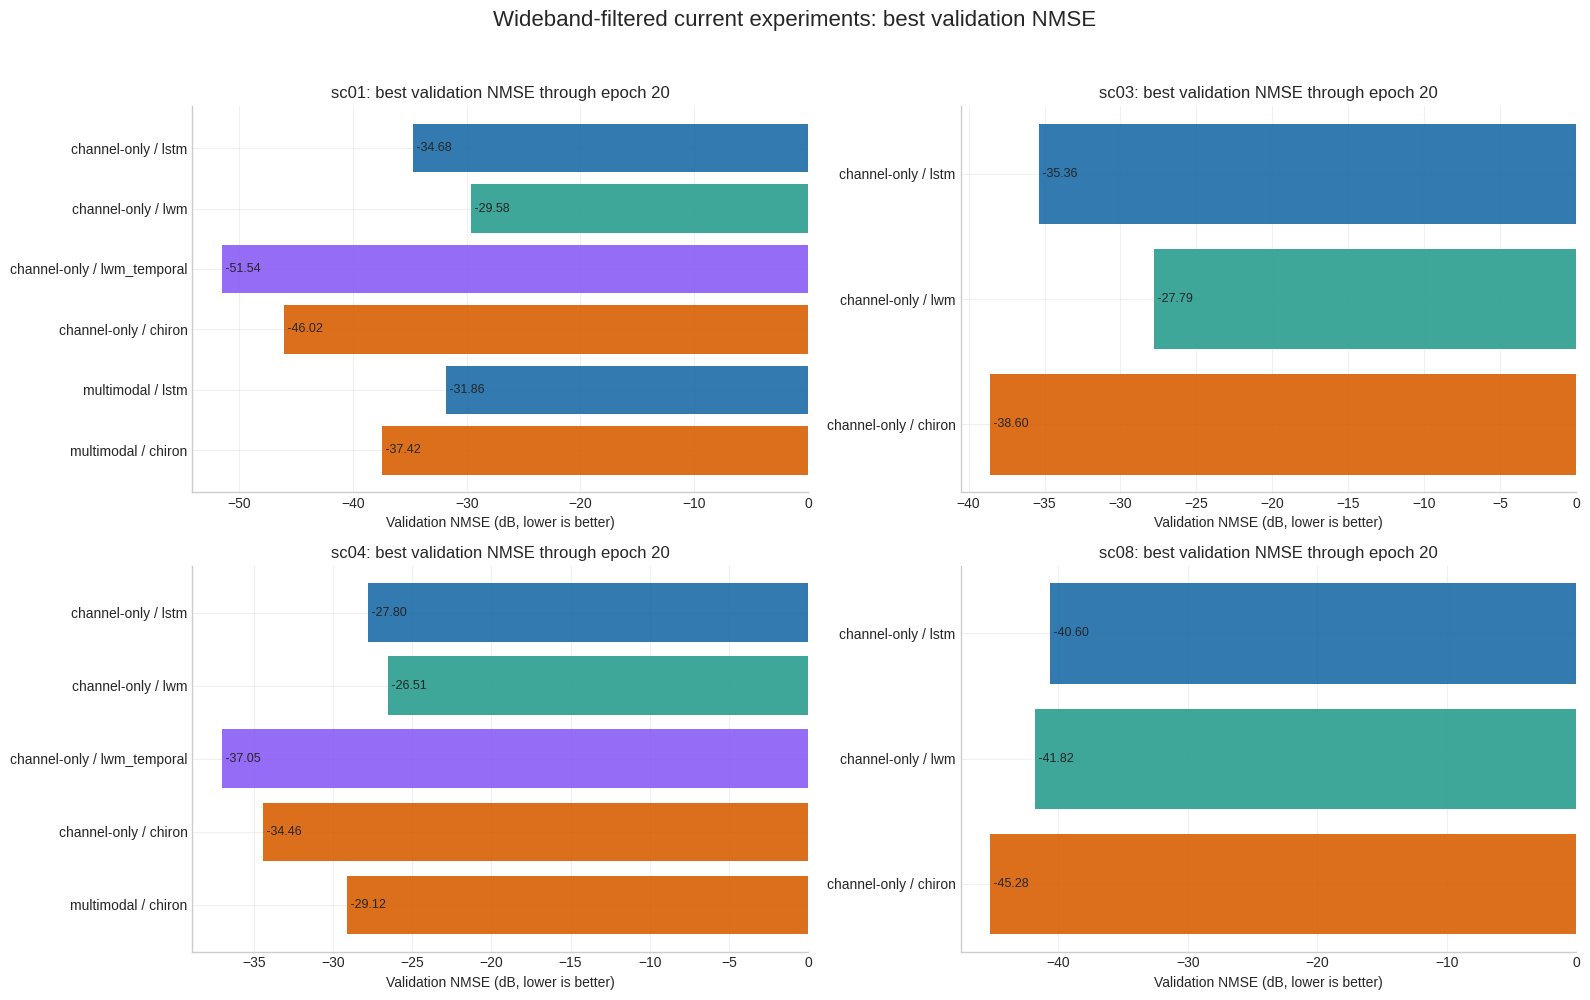

In [5]:
MODEL_COLORS = {
    'lstm': '#1b6ca8',
    'lwm': '#2a9d8f',
    'lwm_temporal': '#8a5cf6',
    'chiron': '#d95f02',
}
MODE_LABELS = {'channel_only': 'channel-only', 'multimodal': 'multimodal', 'image_only': 'image-only'}
MODE_MARKERS = {'channel_only': 'o', 'multimodal': 's', 'image_only': '^'}
mode_order_map = {m: i for i, m in enumerate(MODE_ORDER)}
model_order_map = {m: i for i, m in enumerate(MODEL_ORDER)}

def ordered_values(values, order):
    values = list(values)
    return [x for x in order if x in values] + sorted([x for x in values if x not in order])

def sorted_runs(df):
    out = df.copy()
    out['mode_order'] = out['mode'].map(mode_order_map).fillna(99)
    out['model_order'] = out['model'].map(model_order_map).fillna(99)
    return out.sort_values(['scenario', 'mode_order', 'model_order'])

def label_for(row):
    return f"{MODE_LABELS.get(row['mode'], row['mode'])} / {row['model']}"

def style_axis(ax):
    ax.grid(True, alpha=0.28)
    ax.spines[['top', 'right']].set_visible(False)

scenarios = ordered_values(canonical['scenario'].dropna().unique(), ['sc01', 'sc03', 'sc04', 'sc08'])

fig, axes = plt.subplots(2, 2, figsize=(16, 10), squeeze=False)
for ax, scenario in zip(axes.ravel(), scenarios):
    sub = sorted_runs(canonical[canonical['scenario'].eq(scenario)])
    labels = [label_for(row) for _, row in sub.iterrows()]
    colors = [MODEL_COLORS.get(row['model'], '#777777') for _, row in sub.iterrows()]
    bars = ax.barh(labels, sub['best_val_nmse_db'], color=colors, alpha=0.9)
    ax.set_title(f'{scenario}: best validation NMSE through epoch {EPOCH_LIMIT}')
    ax.set_xlabel('Validation NMSE (dB, lower is better)')
    ax.invert_yaxis()
    style_axis(ax)
    for bar, value in zip(bars, sub['best_val_nmse_db']):
        ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.2f}', va='center', fontsize=9)
for ax in axes.ravel()[len(scenarios):]:
    ax.axis('off')
fig.suptitle('Wideband-filtered current experiments: best validation NMSE', fontsize=16, y=0.995)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## Validation Curves Over Epoch

x-axis: epoch. y-axis: validation metric.

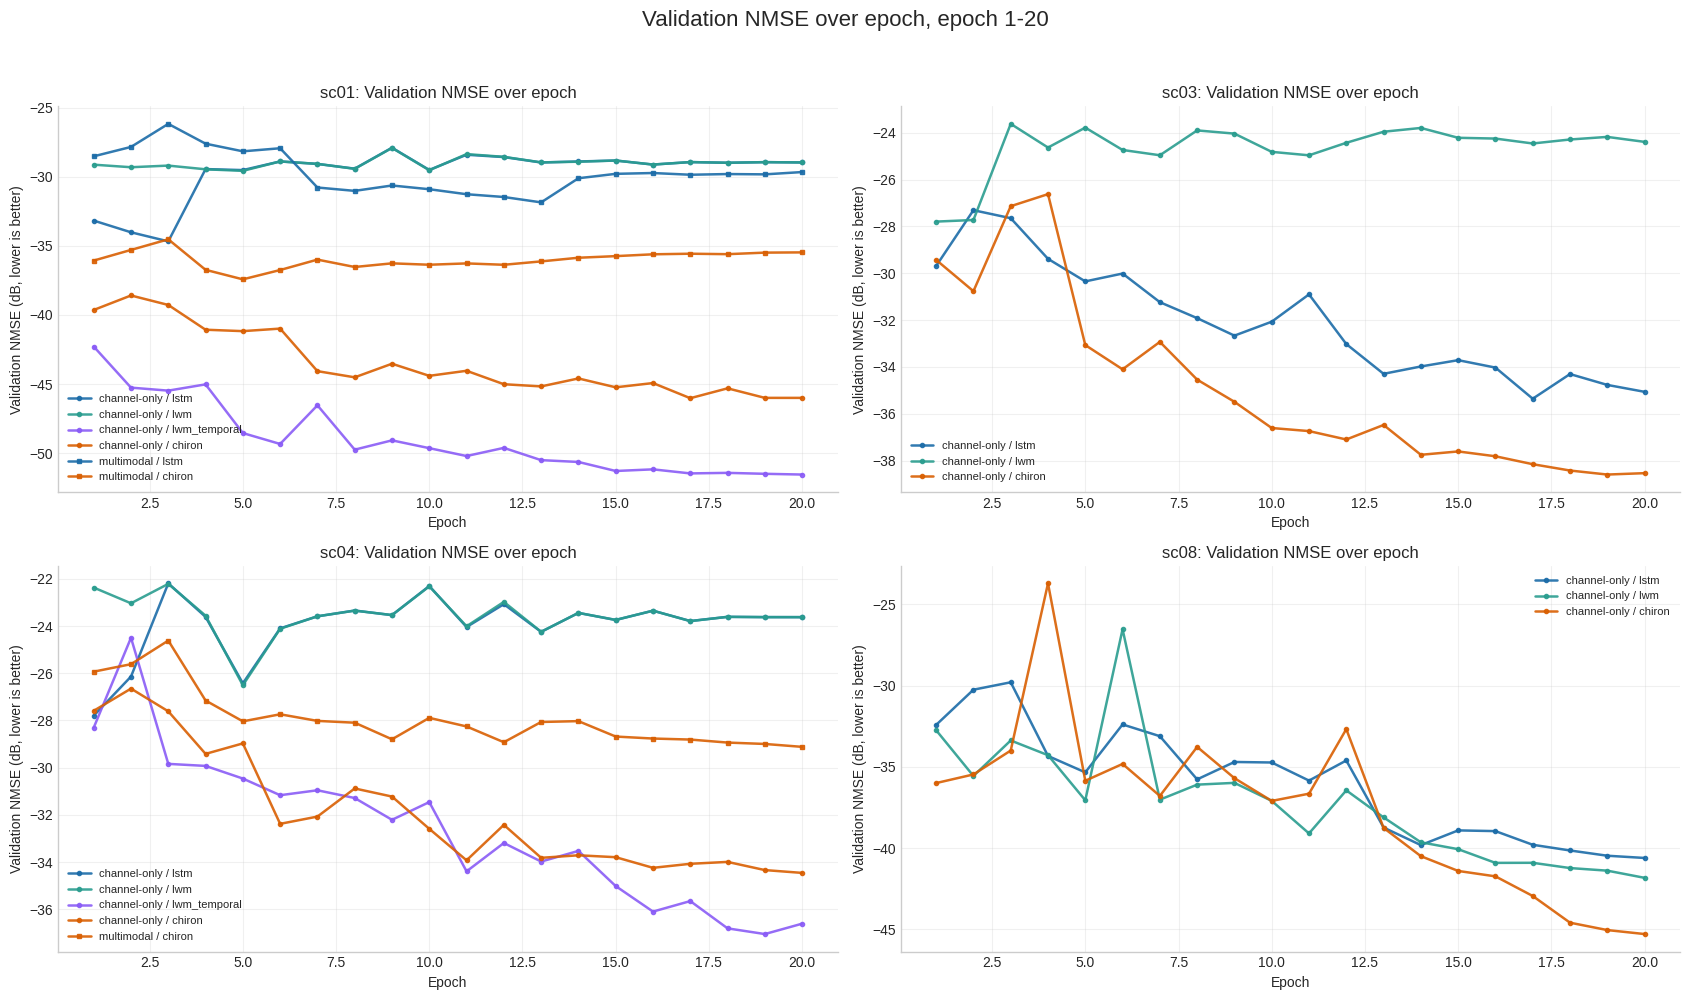

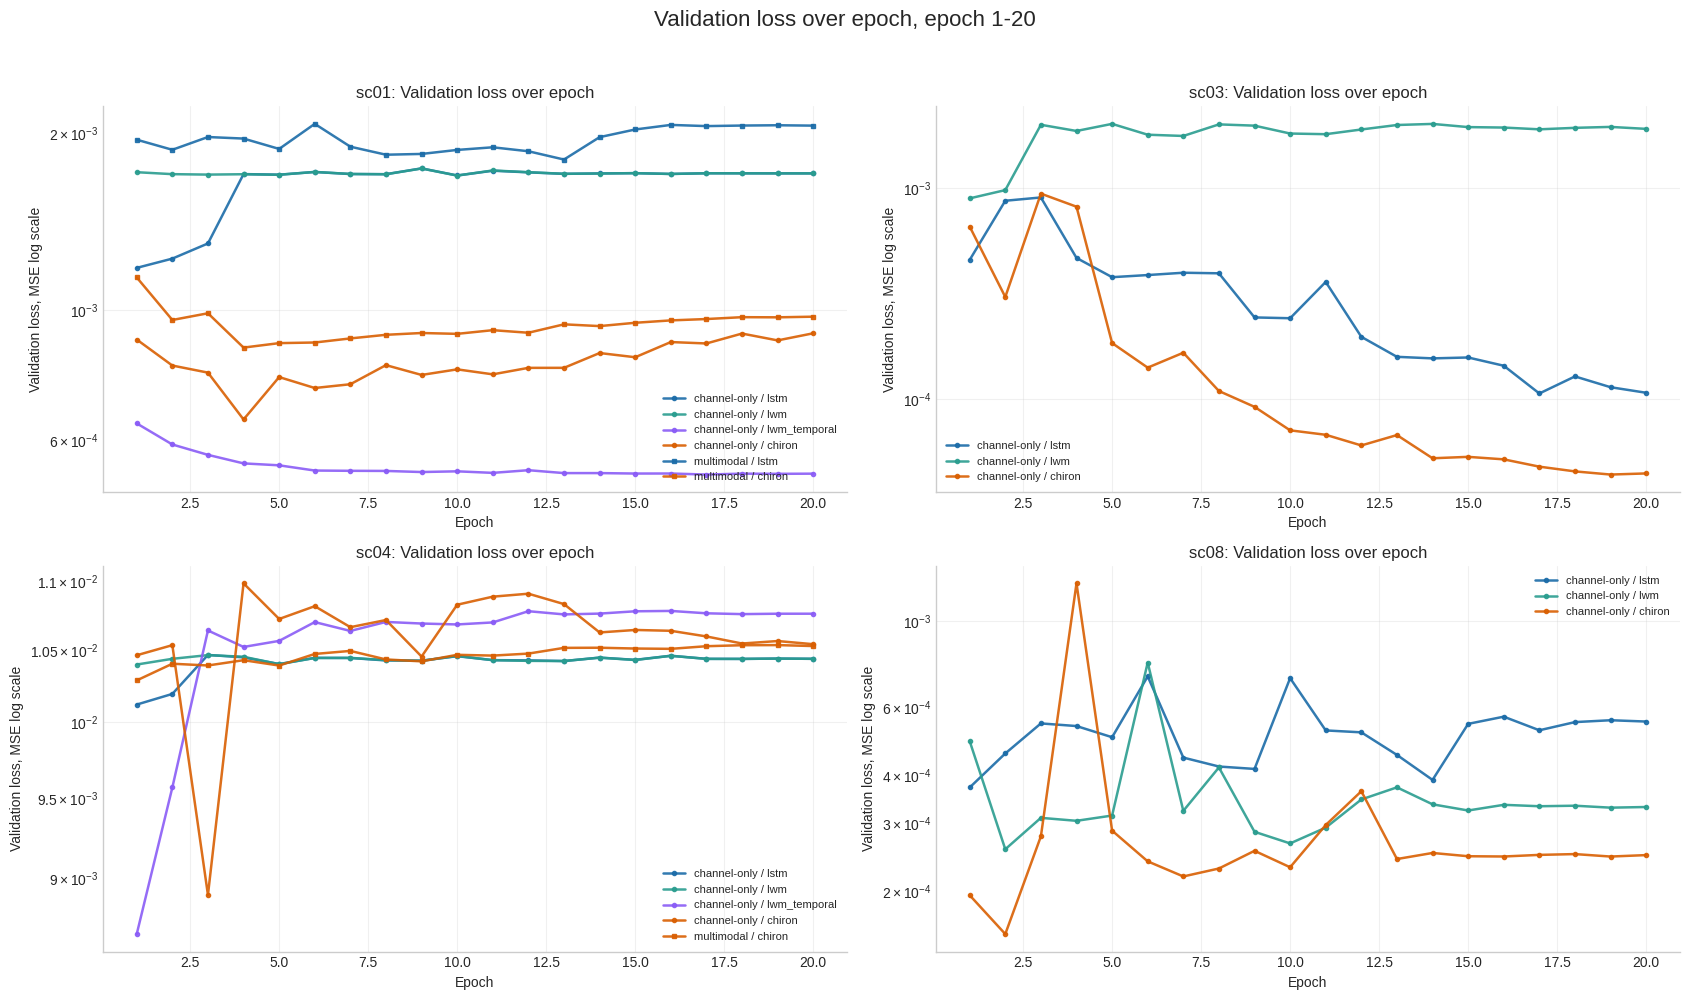

In [6]:
canonical_run_ids = set(canonical['run_id'])
plot_history = limited[limited['run_id'].isin(canonical_run_ids)].copy()

for metric, ylabel, title, use_log in [
    ('val_nmse_db', 'Validation NMSE (dB, lower is better)', 'Validation NMSE over epoch', False),
    ('val_loss', 'Validation loss, MSE log scale', 'Validation loss over epoch', True),
]:
    fig, axes = plt.subplots(2, 2, figsize=(17, 10), squeeze=False)
    for ax, scenario in zip(axes.ravel(), scenarios):
        sub_summary = sorted_runs(canonical[canonical['scenario'].eq(scenario)])
        for _, row in sub_summary.iterrows():
            run = plot_history[plot_history['run_id'].eq(row['run_id'])].sort_values('epoch')
            ax.plot(
                run['epoch'], run[metric],
                label=label_for(row),
                color=MODEL_COLORS.get(row['model'], '#777777'),
                marker=MODE_MARKERS.get(row['mode'], 'o'),
                markersize=3,
                linewidth=1.8,
                alpha=0.9,
            )
        if use_log:
            ax.set_yscale('log')
        ax.set_title(f'{scenario}: {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        style_axis(ax)
        ax.legend(fontsize=8)
    for ax in axes.ravel()[len(scenarios):]:
        ax.axis('off')
    fig.suptitle(f'{title}, epoch 1-{EPOCH_LIMIT}', fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Train vs Validation Curves

Solid lines are validation metrics. Dashed lines are training metrics.

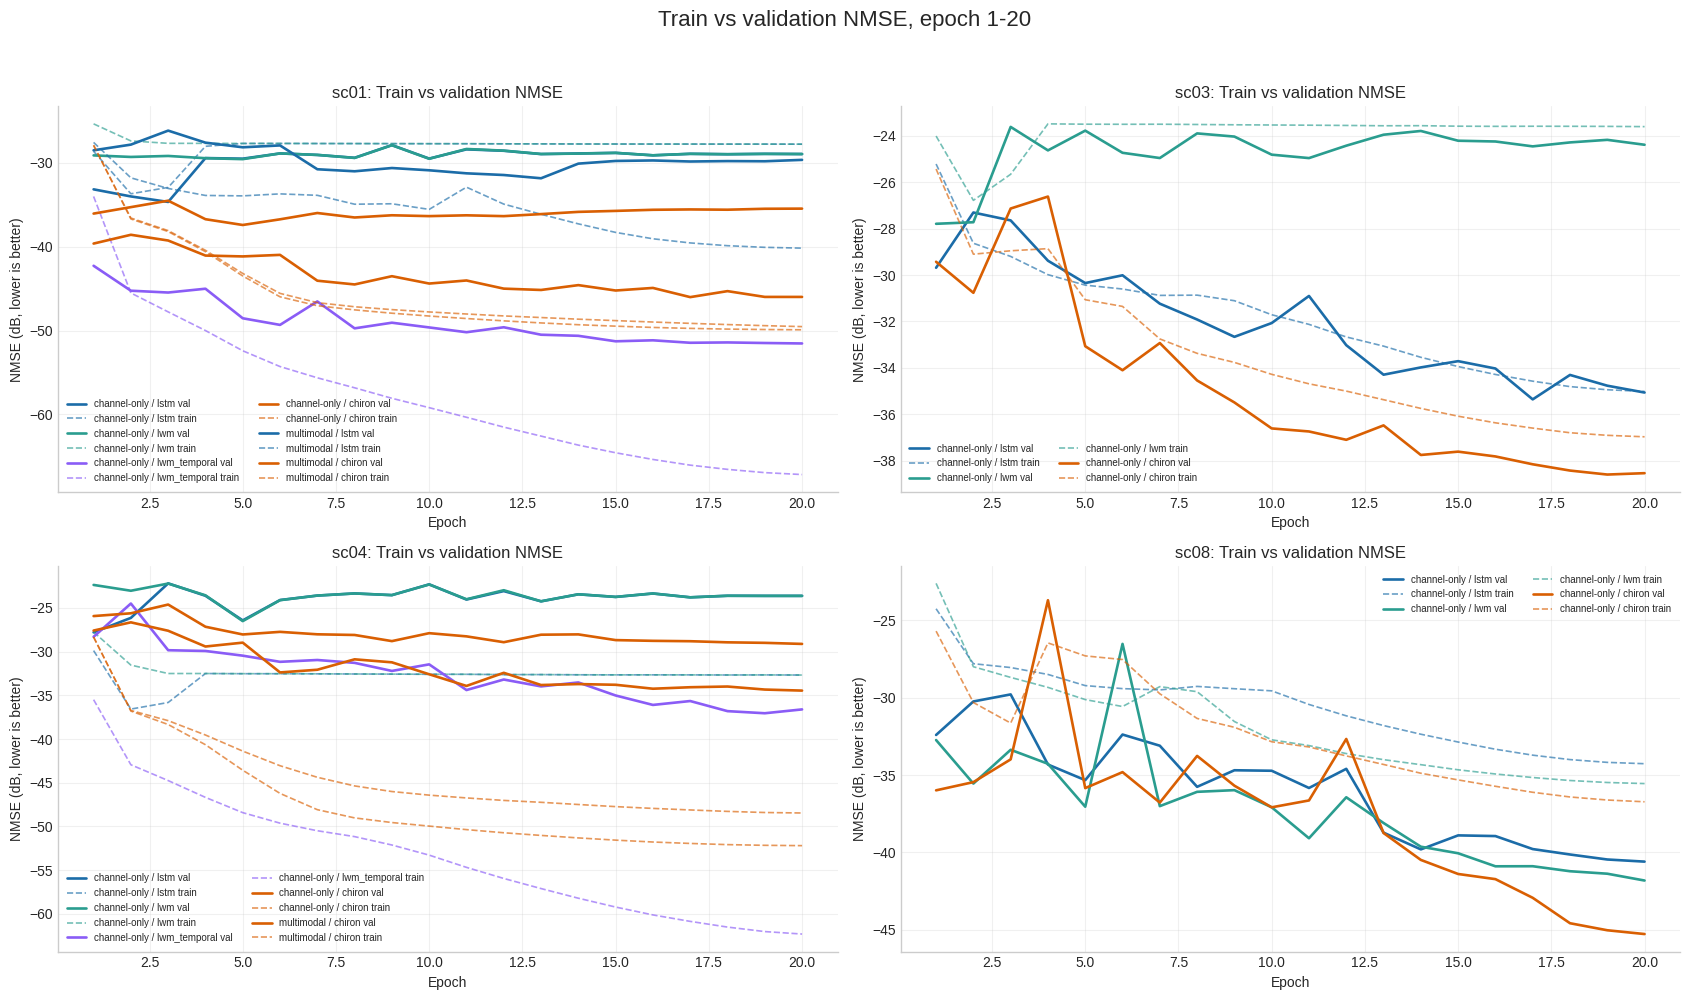

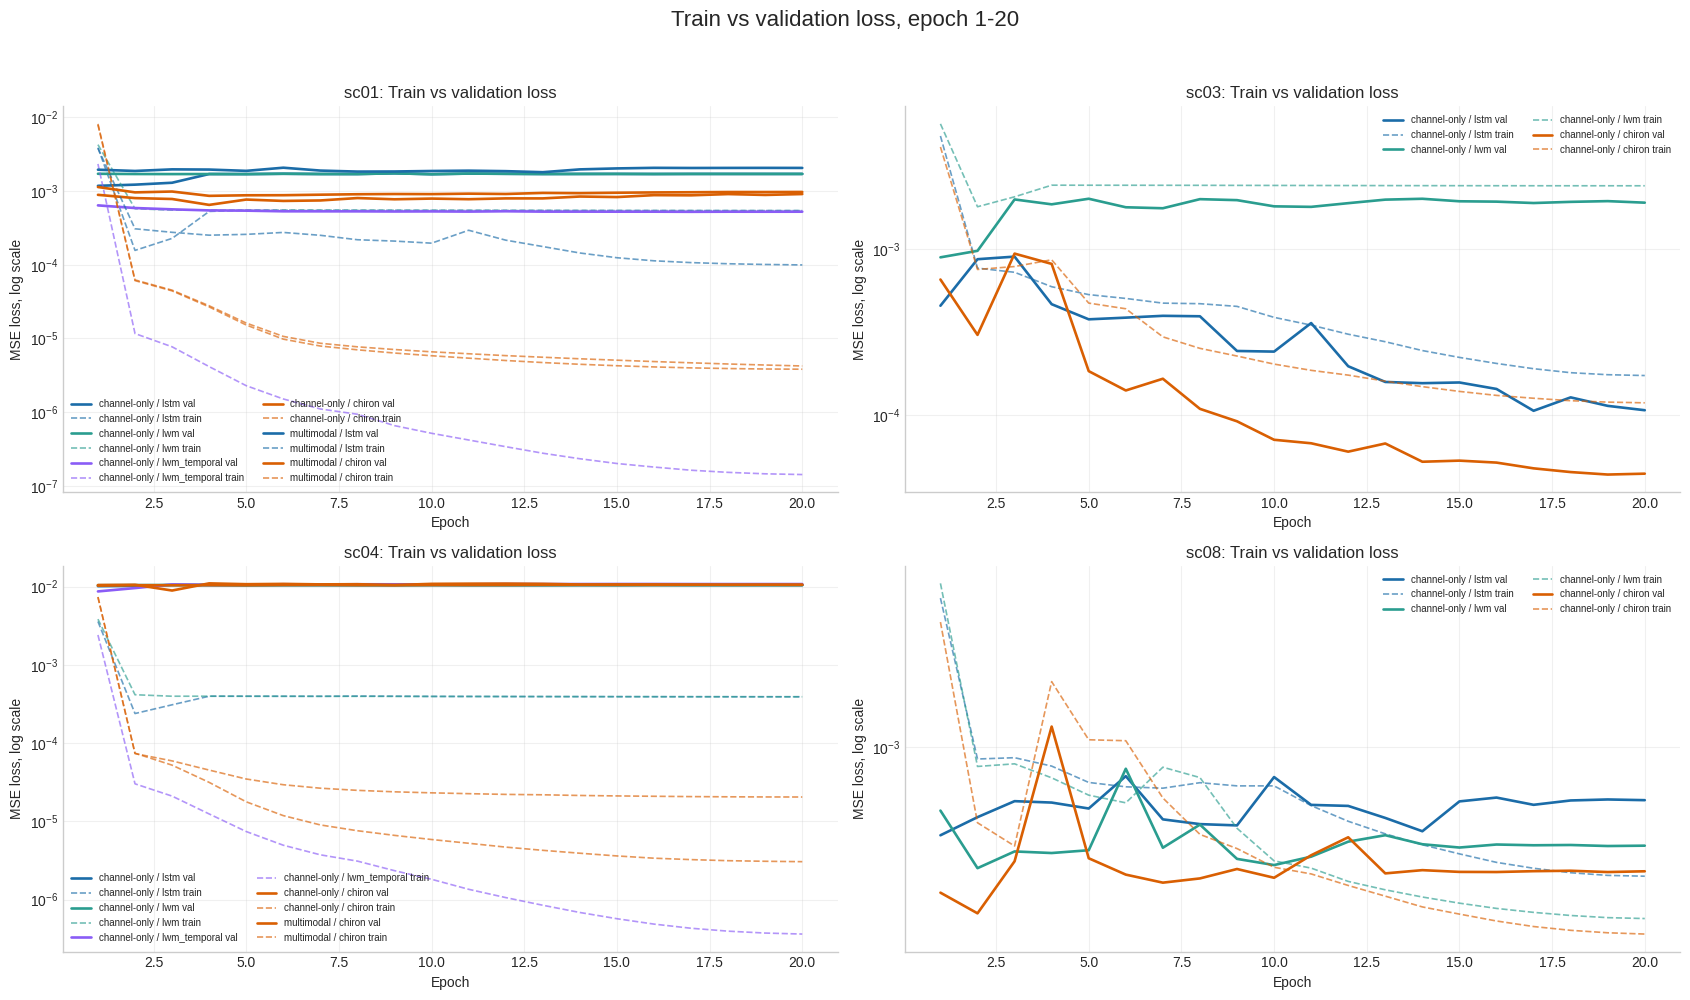

In [7]:
for metric_pair, ylabel, title, use_log in [
    (('train_nmse_db', 'val_nmse_db'), 'NMSE (dB, lower is better)', 'Train vs validation NMSE', False),
    (('train_loss', 'val_loss'), 'MSE loss, log scale', 'Train vs validation loss', True),
]:
    train_metric, val_metric = metric_pair
    fig, axes = plt.subplots(2, 2, figsize=(17, 10), squeeze=False)
    for ax, scenario in zip(axes.ravel(), scenarios):
        sub_summary = sorted_runs(canonical[canonical['scenario'].eq(scenario)])
        for _, row in sub_summary.iterrows():
            run = plot_history[plot_history['run_id'].eq(row['run_id'])].sort_values('epoch')
            color = MODEL_COLORS.get(row['model'], '#777777')
            ax.plot(run['epoch'], run[val_metric], color=color, linewidth=1.9, label=f"{label_for(row)} val")
            ax.plot(run['epoch'], run[train_metric], color=color, linewidth=1.2, linestyle='--', alpha=0.65, label=f"{label_for(row)} train")
        if use_log:
            ax.set_yscale('log')
        ax.set_title(f'{scenario}: {title}')
        ax.set_xlabel('Epoch')
        ax.set_ylabel(ylabel)
        style_axis(ax)
        ax.legend(fontsize=7, ncol=2)
    for ax in axes.ravel()[len(scenarios):]:
        ax.axis('off')
    fig.suptitle(f'{title}, epoch 1-{EPOCH_LIMIT}', fontsize=16, y=0.995)
    plt.tight_layout(rect=[0, 0, 1, 0.97])
    plt.show()

## Train-Validation Gap

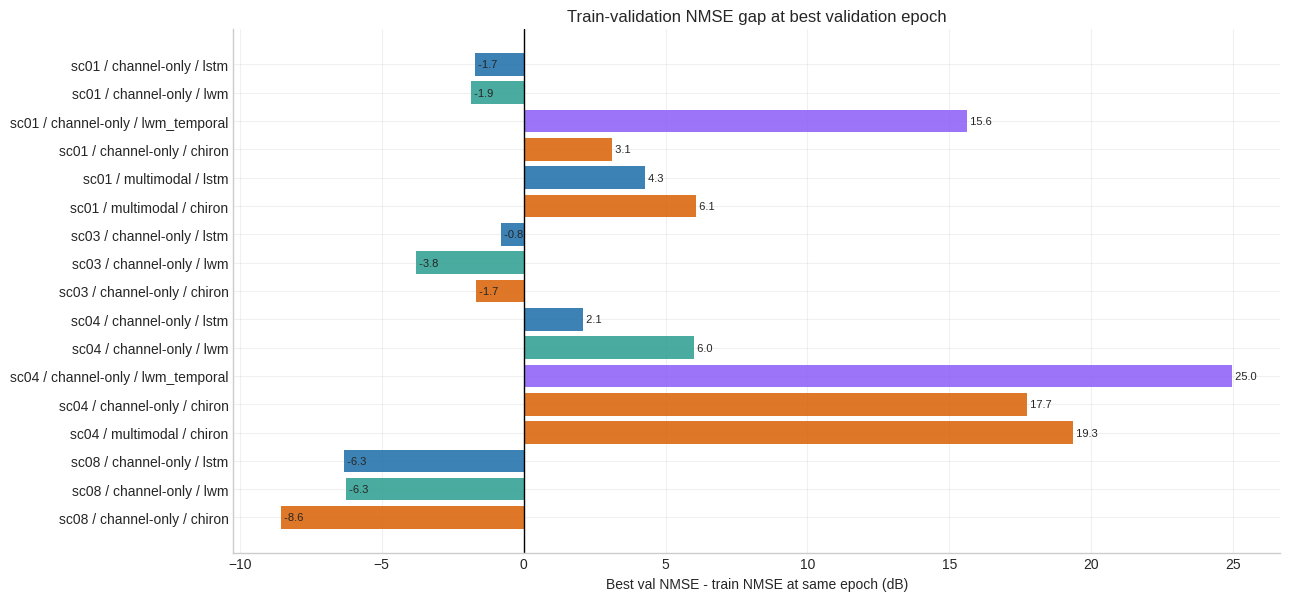

In [ ]:
gap_df = sorted_runs(canonical).copy()
gap_df['label'] = gap_df['scenario'] + ' / ' + gap_df['mode'].map(MODE_LABELS).fillna(gap_df['mode']) + ' / ' + gap_df['model']

fig, ax = plt.subplots(figsize=(13, max(6, 0.36 * len(gap_df))))
colors = [MODEL_COLORS.get(model, '#777777') for model in gap_df['model']]
bars = ax.barh(gap_df['label'], gap_df['train_val_nmse_gap_db_at_best'], color=colors, alpha=0.85)
ax.axvline(0, color='black', linewidth=1)
ax.set_title('Train-validation NMSE gap at best validation epoch')
ax.set_xlabel('Best val NMSE - train NMSE at same epoch (dB)')ㅉ
ax.invert_yaxis()
style_axis(ax)
for bar, value in zip(bars, gap_df['train_val_nmse_gap_db_at_best']):
    ax.text(value, bar.get_y() + bar.get_height() / 2, f' {value:.1f}', va='center', fontsize=8)
plt.tight_layout()
plt.show()